# SleepSense — SHAP Explainability & Anomaly Analysis

This notebook performs post-hoc model explainability using SHAP values and analyzes the daily behavioral anomalies flagged by our Isolation Forest models.

In [1]:
import os
import sys
sys.path.insert(0, os.path.abspath(os.path.join(os.getcwd(), '..')))
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import shap
from src.models.trainer import load_data
from src.evaluation.explainability import explain_dataset, plot_shap_summary, load_xgb_pipeline

# Set plotting style
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

## 1. SHAP Global Feature Importance

Let's compute SHAP values for all daily behavioral predictions to see what drivers most heavily impact our sleep predictions globally.

In [2]:
df, X, y, user_ids = load_data()

print("Computing SHAP values... ")
explainer, shap_values, X_preprocessed = explain_dataset(X, save_importance=True)
print("SHAP values computed and global feature importance saved successfully.")

Computing SHAP values... 
Saved global feature importance to C:\Users\HP\Desktop\Semester 7\AI\Project\SleepSense\models\registry\feature_importance.json
SHAP values computed and global feature importance saved successfully.


## 2. Visualize SHAP Global Importances

Let's display the SHAP summary plots (beeswarm and bar chart) to analyze the positive/negative impact direction of features.

Saved SHAP summary plot to ../implementation/shap_summary_beeswarm.png


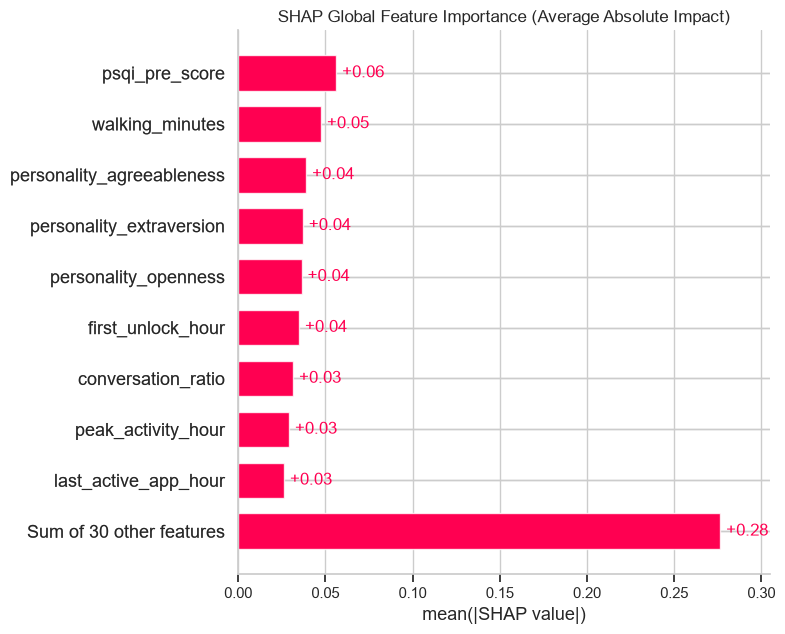

In [3]:
# Save beeswarm summary plot
os.makedirs('../implementation', exist_ok=True)
os.makedirs('implementation', exist_ok=True)
shap_summary_path = '../implementation/shap_summary_beeswarm.png'
try:
    plot_shap_summary(shap_values, X_preprocessed, shap_summary_path)
except Exception:
    plot_shap_summary(shap_values, X_preprocessed, 'implementation/shap_summary_beeswarm.png')

# Plot SHAP global bar chart in notebook
plt.figure(figsize=(10, 6))
shap.plots.bar(shap_values, show=False)
plt.title("SHAP Global Feature Importance (Average Absolute Impact)")
plt.tight_layout()
try:
    plt.savefig('../implementation/shap_importance_bar.png', dpi=150)
except Exception:
    plt.savefig('implementation/shap_importance_bar.png', dpi=150)
plt.show()

## 3. Behavioral Anomaly Detection

Now let's load our trained per-user Isolation Forest model and inspect behavioral anomalies across days.

In [4]:
iso_model_path = '../models/registry/isoforest_model.pkl'
if not os.path.exists(iso_model_path):
    iso_model_path = 'models/registry/isoforest_model.pkl'

user_iso = joblib.load(iso_model_path)

# Compile df with user_id and date for prediction
df_anomaly = X.copy()
df_anomaly['user_id'] = user_ids

anomaly_scores = user_iso.predict_anomaly_score(df_anomaly)
anomaly_flags = user_iso.predict_anomaly_flag(df_anomaly)

df['anomaly_score'] = anomaly_scores
df['anomaly_flag'] = anomaly_flags

total_anomalies = df['anomaly_flag'].sum()
print(f"Total behavior anomalies flagged: {total_anomalies} out of {len(df)} days ({total_anomalies/len(df)*100:.1f}%)")

C:\Users\HP\anaconda3\envs\sleepsense-ai\Lib\site-packages\sklearn\impute\_base.py:647: UserWarning: Skipping features without any observed values: ['mood_happy']. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(
C:\Users\HP\anaconda3\envs\sleepsense-ai\Lib\site-packages\sklearn\impute\_base.py:647: UserWarning: Skipping features without any observed values: ['mood_happy']. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(
C:\Users\HP\anaconda3\envs\sleepsense-ai\Lib\site-packages\sklearn\impute\_base.py:647: UserWarning: Skipping features without any observed values: ['mood_happy']. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(
C:\Users\HP\anaconda3\envs\sleepsense-ai\Lib\site-packages\sklearn\impute\_base.py:647: UserWarning: Skipping features without any observed values: ['mood_happy']. At least one non-missing value is needed for imputati

C:\Users\HP\anaconda3\envs\sleepsense-ai\Lib\site-packages\sklearn\impute\_base.py:647: UserWarning: Skipping features without any observed values: ['mood_happy']. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(
C:\Users\HP\anaconda3\envs\sleepsense-ai\Lib\site-packages\sklearn\impute\_base.py:647: UserWarning: Skipping features without any observed values: ['mood_happy']. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(
C:\Users\HP\anaconda3\envs\sleepsense-ai\Lib\site-packages\sklearn\impute\_base.py:647: UserWarning: Skipping features without any observed values: ['mood_happy']. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(
C:\Users\HP\anaconda3\envs\sleepsense-ai\Lib\site-packages\sklearn\impute\_base.py:647: UserWarning: Skipping features without any observed values: ['mood_happy']. At least one non-missing value is needed for imputati

C:\Users\HP\anaconda3\envs\sleepsense-ai\Lib\site-packages\sklearn\impute\_base.py:647: UserWarning: Skipping features without any observed values: ['mood_happy']. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(
C:\Users\HP\anaconda3\envs\sleepsense-ai\Lib\site-packages\sklearn\impute\_base.py:647: UserWarning: Skipping features without any observed values: ['mood_happy']. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(
C:\Users\HP\anaconda3\envs\sleepsense-ai\Lib\site-packages\sklearn\impute\_base.py:647: UserWarning: Skipping features without any observed values: ['mood_happy']. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(
C:\Users\HP\anaconda3\envs\sleepsense-ai\Lib\site-packages\sklearn\impute\_base.py:647: UserWarning: Skipping features without any observed values: ['mood_happy']. At least one non-missing value is needed for imputati

C:\Users\HP\anaconda3\envs\sleepsense-ai\Lib\site-packages\sklearn\impute\_base.py:647: UserWarning: Skipping features without any observed values: ['mood_happy']. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(
C:\Users\HP\anaconda3\envs\sleepsense-ai\Lib\site-packages\sklearn\impute\_base.py:647: UserWarning: Skipping features without any observed values: ['mood_happy']. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(
C:\Users\HP\anaconda3\envs\sleepsense-ai\Lib\site-packages\sklearn\impute\_base.py:647: UserWarning: Skipping features without any observed values: ['mood_happy']. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(
C:\Users\HP\anaconda3\envs\sleepsense-ai\Lib\site-packages\sklearn\impute\_base.py:647: UserWarning: Skipping features without any observed values: ['mood_happy']. At least one non-missing value is needed for imputati

C:\Users\HP\anaconda3\envs\sleepsense-ai\Lib\site-packages\sklearn\impute\_base.py:647: UserWarning: Skipping features without any observed values: ['mood_happy']. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(
C:\Users\HP\anaconda3\envs\sleepsense-ai\Lib\site-packages\sklearn\impute\_base.py:647: UserWarning: Skipping features without any observed values: ['mood_happy']. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(
C:\Users\HP\anaconda3\envs\sleepsense-ai\Lib\site-packages\sklearn\impute\_base.py:647: UserWarning: Skipping features without any observed values: ['mood_happy']. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(
C:\Users\HP\anaconda3\envs\sleepsense-ai\Lib\site-packages\sklearn\impute\_base.py:647: UserWarning: Skipping features without any observed values: ['mood_happy']. At least one non-missing value is needed for imputati

...

C:\Users\HP\anaconda3\envs\sleepsense-ai\Lib\site-packages\sklearn\impute\_base.py:647: UserWarning: Skipping features without any observed values: ['mood_happy']. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(
C:\Users\HP\anaconda3\envs\sleepsense-ai\Lib\site-packages\sklearn\impute\_base.py:647: UserWarning: Skipping features without any observed values: ['mood_happy']. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(
C:\Users\HP\anaconda3\envs\sleepsense-ai\Lib\site-packages\sklearn\impute\_base.py:647: UserWarning: Skipping features without any observed values: ['mood_happy']. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(
C:\Users\HP\anaconda3\envs\sleepsense-ai\Lib\site-packages\sklearn\impute\_base.py:647: UserWarning: Skipping features without any observed values: ['mood_happy']. At least one non-missing value is needed for imputati

C:\Users\HP\anaconda3\envs\sleepsense-ai\Lib\site-packages\sklearn\impute\_base.py:647: UserWarning: Skipping features without any observed values: ['mood_happy']. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(
C:\Users\HP\anaconda3\envs\sleepsense-ai\Lib\site-packages\sklearn\impute\_base.py:647: UserWarning: Skipping features without any observed values: ['mood_happy']. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(
C:\Users\HP\anaconda3\envs\sleepsense-ai\Lib\site-packages\sklearn\impute\_base.py:647: UserWarning: Skipping features without any observed values: ['mood_happy']. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(
C:\Users\HP\anaconda3\envs\sleepsense-ai\Lib\site-packages\sklearn\impute\_base.py:647: UserWarning: Skipping features without any observed values: ['mood_happy']. At least one non-missing value is needed for imputati

C:\Users\HP\anaconda3\envs\sleepsense-ai\Lib\site-packages\sklearn\impute\_base.py:647: UserWarning: Skipping features without any observed values: ['mood_happy']. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(
C:\Users\HP\anaconda3\envs\sleepsense-ai\Lib\site-packages\sklearn\impute\_base.py:647: UserWarning: Skipping features without any observed values: ['mood_happy']. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(
C:\Users\HP\anaconda3\envs\sleepsense-ai\Lib\site-packages\sklearn\impute\_base.py:647: UserWarning: Skipping features without any observed values: ['mood_happy']. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(
C:\Users\HP\anaconda3\envs\sleepsense-ai\Lib\site-packages\sklearn\impute\_base.py:647: UserWarning: Skipping features without any observed values: ['mood_happy']. At least one non-missing value is needed for imputati

C:\Users\HP\anaconda3\envs\sleepsense-ai\Lib\site-packages\sklearn\impute\_base.py:647: UserWarning: Skipping features without any observed values: ['mood_happy']. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(
C:\Users\HP\anaconda3\envs\sleepsense-ai\Lib\site-packages\sklearn\impute\_base.py:647: UserWarning: Skipping features without any observed values: ['mood_happy']. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(
C:\Users\HP\anaconda3\envs\sleepsense-ai\Lib\site-packages\sklearn\impute\_base.py:647: UserWarning: Skipping features without any observed values: ['mood_happy']. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(
C:\Users\HP\anaconda3\envs\sleepsense-ai\Lib\site-packages\sklearn\impute\_base.py:647: UserWarning: Skipping features without any observed values: ['mood_happy']. At least one non-missing value is needed for imputati

Total behavior anomalies flagged: 145 out of 1321 days (11.0%)


## 4. Visualize Anomaly Score Distribution

Let's visualize the distribution of anomaly scores. Scores closer to negative values represent highly atypical behavioral days for a user.

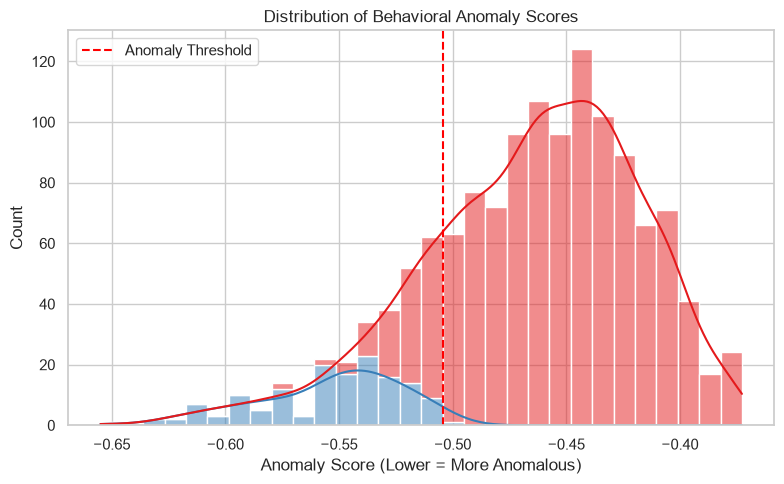

In [5]:
plt.figure(figsize=(8, 5))
sns.histplot(data=df, x='anomaly_score', hue='anomaly_flag', bins=30, kde=True, palette='Set1', multiple='stack')
plt.title("Distribution of Behavioral Anomaly Scores")
plt.xlabel("Anomaly Score (Lower = More Anomalous)")
plt.ylabel("Count")
plt.axvline(x=df[df['anomaly_flag'] == 1]['anomaly_score'].max(), color='red', linestyle='--', label='Anomaly Threshold')
plt.legend()
plt.tight_layout()
try:
    plt.savefig('../implementation/anomaly_score_distribution.png', dpi=150)
except Exception:
    plt.savefig('implementation/anomaly_score_distribution.png', dpi=150)
plt.show()

## 5. Local Anomaly Example: Analyzing a Flagged Day

Let's look at one specific anomalous day for a user and compare their behavior on that day against their historical average.

In [6]:
# Find a user with at least one anomaly
anomalous_users = df[df['anomaly_flag'] == 1]['user_id'].unique()
if len(anomalous_users) > 0:
    selected_user = anomalous_users[0]
    user_days = df[df['user_id'] == selected_user]
    
    # Get the anomalous day and normal days
    anom_day = user_days[user_days['anomaly_flag'] == 1].iloc[0]
    normal_days_mean = user_days[user_days['anomaly_flag'] == 0].mean(numeric_only=True)
    
    # Compare key features
    compare_feats = ['unlock_count_late_night', 'stationary_ratio', 'walking_minutes', 'app_entertainment_evening_min', 'stress_level']
    comparison_df = pd.DataFrame({
        'Feature': compare_feats,
        'Anomalous Day Value': [anom_day[f] for f in compare_feats],
        'Historical Mean': [normal_days_mean[f] for f in compare_feats]
    })
    print(f"Behavior comparison for user {selected_user} on anomalous day ({anom_day['date']}):")
    print(comparison_df)
else:
    print("No anomalous users found.")

Behavior comparison for user u00 on anomalous day (2013-03-31):
                         Feature  Anomalous Day Value  Historical Mean
0        unlock_count_late_night             1.000000         0.372093
1               stationary_ratio             0.808346         0.875076
2                walking_minutes           130.434783        91.405653
3  app_entertainment_evening_min           100.000000         9.302326
4                   stress_level             4.500000         2.335859
